In [48]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json 
%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter

import re 

## Plot results from Popham-style conditions using SWC stimuli

### Import human data

In [49]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("cocktail_party_popham_swc_word_recognition/data/*.json"))

# import vocab dict for matching audio & responses 
# word_and_speaker_encodings = pickle.load( open("/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
# # ix_to_word_map = {v:k for k,v in class_map.items()}
# class_map = word_and_speaker_encodings['word_idx_to_word']
len(human_fnames)


68

## Process Human Results

In [50]:
## Get all subject data into one df for analysis

def get_part_df(fname):
    part_data = json.load(open(fname, 'r'))
    # print(f"{fname.stem} success {part_data[0]['success']}")
    part_df = pd.DataFrame.from_records(part_data)
    ## Forward fill stim presentation entry to word response entry
    responses = part_df.loc[part_df.trial_type.isin(['audio-keyboard-response','dictionary-text']), ['trial_index', 'stimulus']]
    responses = responses.ffill()
    part_df.loc[part_df['trial_index'].isin(responses["trial_index"].values), 'stimulus'] = responses.stimulus
    return part_df

dfs = []
for fname in human_fnames:
    try:
        dfs.append(get_part_df(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)

## Filter for those who passed headphone check 
results_df = results_df[results_df.hc_passed == True]


## Add snr and condition names as columns - unpack from file code in file names 

import re
### Get condition map
with open('swc_popham_exmpt_2024_cond_manifest.pkl', 'rb') as f:
    stim_cond_map = pickle.load(f)

stim_cond_map = {f"condition_{k:02}": v for k,v in stim_cond_map.items()}

## Map wav str to stim_type using condition dict
def get_stim_snr_and_cond(stim_str, stim_cond_map=stim_cond_map):
    target_harm, dist_harm = None,  None 
    if isinstance(stim_str, str) and not stim_str.startswith('<'):
        # print(stim_str)
        cond_str = re.search("condition_(-?\d+)", stim_str)
        if cond_str:
            cond_str = cond_str.group(0)
            target_harm = stim_cond_map[cond_str]['target_harmonicity']
            dist_harm = stim_cond_map[cond_str]['distractor_harmonicity']
            if dist_harm is None:
                dist_harm = 'No Distractor'
            target_harm = target_harm.title()
            dist_harm = dist_harm.title()
        elif 'catch' in stim_str:
            target_harm = 'catch_trial'
            dist_harm = 'No Distractor'
    return target_harm, dist_harm

# add as columns 
results_df['target_harmonicity'], results_df['distractor_harmonicity'] = zip(*results_df['stimulus'].apply(get_stim_snr_and_cond))

# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str]


# screen based on completion 
total_trials = 192 
full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').target_harmonicity.count() == total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]

# # Add accuracy 
trial_results['accuracy'] = (trial_results['response'] == trial_results['correct_response']).astype('int')


Unterminated string starting at: line 1 column 72251 (char 72250)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_popham_swc_word_recognition/data/subj_55b899c5fdf99b7323bc60e0.json
Unterminated string starting at: line 1 column 277004 (char 277003)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_popham_swc_word_recognition/data/subj_59b5a275c05bb50001eb3c4b.json


Unterminated string starting at: line 1 column 289094 (char 289093)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_popham_swc_word_recognition/data/subj_5f6b8c1f5622370b0c94d597.json
Expecting ',' delimiter: line 1 column 132472 (char 132471)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_popham_swc_word_recognition/data/subj_65f07c8102b4c1d4aa644c4a.json


In [51]:
trial_results.groupby('id_subject').target_harmonicity.count()

id_subject
5c8ba607c5366c0001d022cb    192
5e37fb7f1719dd000b3f5c42    192
5f2c1cc33ea8e3068272d06c    192
5fd8ea198512a801831f6b85    192
60e97cc8cfc0ba33080d90fe    192
6127f0663a7eb20ac747eb99    192
6147c5874b61952e42e9b2bd    192
62682277645054f5802459b8    192
6294ce94ea81c4554b141010    192
62a999b8ed876efe5ffe9599    192
62d6d87d91cf24a3c1c0f10c    192
62f3b543dce069211e8e982c    192
6310c063bd0cce86b0289d20    192
6384cfc62b6bf7a232ade8cb    192
63d161c9e0cf5f1b1f7bce5b    192
63d7abeeb49ad49fa7545e44    192
63e51e063af1cc5baf0c72ca    192
63ea4a7fa7d709c8e7887a93    192
63ea6fc5092518554c9b8111    192
644cdee223c4b93bf46c7301    192
6503444cd88ba9004224b69e    192
65599c698363f734b0325aa2    192
65add0950cc74fc6024f5b6a    192
65c1fb3abe42175a96e41b53    192
65dca445b7cc34ec8acfc80f    192
6606d6fdb6fcbf4263e80df9    192
66099d3fa3579e4e79fa013c    192
Name: target_harmonicity, dtype: int64

In [82]:
catch_trial_particiapnt_performance = trial_results[trial_results.target_harmonicity == 'catch_trial'].groupby('id_subject').accuracy.mean()
print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 11/12].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]

analysis_df = good_results[(~good_results.target_harmonicity.isnull()) & (~good_results.response.isna())]
analysis_df = analysis_df[analysis_df.target_harmonicity != 'catch_trial']

analysis_df.groupby('id_subject').target_harmonicity.count()

N total participants  27
N good participants  23


id_subject
5c8ba607c5366c0001d022cb    180
5e37fb7f1719dd000b3f5c42    180
5f2c1cc33ea8e3068272d06c    180
5fd8ea198512a801831f6b85    180
60e97cc8cfc0ba33080d90fe    180
6147c5874b61952e42e9b2bd    180
62682277645054f5802459b8    180
6294ce94ea81c4554b141010    180
62a999b8ed876efe5ffe9599    180
62d6d87d91cf24a3c1c0f10c    180
62f3b543dce069211e8e982c    180
6384cfc62b6bf7a232ade8cb    180
63d161c9e0cf5f1b1f7bce5b    180
63d7abeeb49ad49fa7545e44    180
63ea4a7fa7d709c8e7887a93    180
63ea6fc5092518554c9b8111    180
644cdee223c4b93bf46c7301    180
6503444cd88ba9004224b69e    180
65599c698363f734b0325aa2    180
65add0950cc74fc6024f5b6a    180
65c1fb3abe42175a96e41b53    180
6606d6fdb6fcbf4263e80df9    180
66099d3fa3579e4e79fa013c    180
Name: target_harmonicity, dtype: int64


## Add re-scored performance based on entries included in excerpt transcripts  

In [83]:
meta_df = pd.read_pickle('/om/user/imgriff/datasets/human_swc_popham_exmpt_2024/source_stim_meta_manifest.pdpkl')

analysis_df = pd.merge(analysis_df,
                        meta_df[['word', 'word_int', 'distractor_word', 'target_transcripts', 'distractor_transcripts', 'gender_cond']],
                        left_on=['correct_response'], right_on=['word'], how='left')     
                        
analysis_df['confusions'] = (analysis_df.response == analysis_df.distractor_word).astype('int')
# add adjusted accuracy and confusions 
target_words = analysis_df.response.values
target_transcripts = analysis_df.target_transcripts.values
distractor_transcripts = analysis_df.distractor_transcripts.values
distractor_words = analysis_df.distractor_word.values


adjusted_acc = np.array([int(target_word in target_transcript)
                            if not isinstance(target_transcript, float) else np.nan
                             for target_word, target_transcript in zip(target_words, target_transcripts)
                              ])

adjusted_confs = np.array([int((target_word in distractor_transcript) or (target_word == distractor_word))
                            if not isinstance(distractor_transcript, float) else np.nan
                             for target_word, distractor_word, distractor_transcript in zip(target_words, distractor_words, distractor_transcripts)
                              ])

analysis_df['adjusted_accuracy'] = adjusted_acc
analysis_df['adjusted_confusions'] = adjusted_confs

In [84]:
# get trial data excluding catch trials 


part_summary_df = (analysis_df.groupby(['id_subject', "target_harmonicity", 'distractor_harmonicity'])
                     .agg({'correct':['mean', 'sem'],
                            'confusions':['mean', 'sem'],
                            'adjusted_accuracy':['mean', 'sem'],
                            'adjusted_confusions':['mean', 'sem', 'count']})
                     .reset_index())

# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]


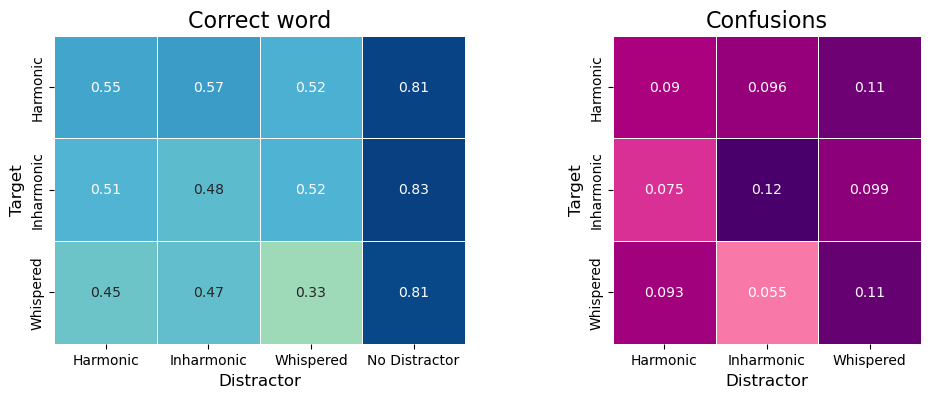

In [85]:

fontsize=16
to_plot = part_summary_df.copy()
to_plot = to_plot[to_plot.target_harmonicity != 'catch_trial']
to_plot.distractor_harmonicity = pd.CategoricalIndex(to_plot.distractor_harmonicity, categories=['Harmonic', 'Inharmonic', 'Whispered', 'No Distractor'])
to_plot.sort_values('distractor_harmonicity', inplace=True)

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)

# cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
# cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])
# make heatmpas square 
axs[0].set_aspect('equal')
axs[1].set_aspect('equal')

# scale size of  colorbar to match heatmap
cbar_kws = {"shrink": .7,}

total_acc = to_plot.groupby(["target_harmonicity", "distractor_harmonicity"])['adjusted_accuracy_mean'].mean()
sns.heatmap(total_acc.unstack(), vmin=0, vmax=total_acc.max(), annot=True, cmap='GnBu', cbar=False, linewidth=.5, ax=axs[0])

total_con = part_summary_df[part_summary_df.distractor_harmonicity != 'No Distractor'].groupby(['target_harmonicity', 'distractor_harmonicity'])['adjusted_confusions_mean'].mean()
sns.heatmap(total_con.unstack(), vmin=0, vmax=total_con.max(), annot=True, cmap='RdPu', cbar=False, linewidth=.5,  ax=axs[1]) # cbar_kws=cbar_kws,

axs[0].set_title("Correct word", fontsize=fontsize)#xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# for ax, row in zip(axs[1], rows):
axs[1].set_title("Confusions", fontsize=fontsize) # , xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# change axis labels for both heatmaps
for ax in axs:
    # ax.set_xticklabels(np.arange(-90, 91, 30), fontsize=fontsize-4)
    # ax.set_yticklabels(np.arange(-90, 91, 30), fontsize=fontsize-4)
    ax.set_xlabel('Distractor', fontsize=fontsize-4)
    ax.set_ylabel('Target', fontsize=fontsize-4)


# plt.savefig(outfig_dest/'harmonicity_heatmaps.svg', trasnsparent=True, bbox_inches='tight')

# plt.tight_layout()

## Set paths and load model results 

In [86]:
## import class maps
import pickle
## load WSN vocab mapping 
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
wsn_word_2_class = word_and_speaker_encodings['word_to_idx']
wsn_class_2_word = word_and_speaker_encodings['word_idx_to_word']
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}


In [87]:
# parent_path = Path('/om2/user/imgriff/projects/torch_2_aud_attn/popham_mono_eval/')
parent_path = Path('/om2/user/imgriff/projects/torch_2_aud_attn/popham_swc_eval/')

model_name = 'word_task_standard_v08'

meta_df = pd.read_pickle('/om/user/imgriff/datasets/human_swc_popham_exmpt_2024/source_stim_meta_manifest.pdpkl')

results_dirs = list(parent_path.rglob(f"*{model_name}/*.csv"))
print(len(results_dirs))

dfs = []

for result_csv in results_dirs:
    df = pd.read_csv(result_csv)
    df['target_harmonicity'] = result_csv.stem.split('_target')[0].split('_')[-1].title()
    dist_harm = result_csv.stem.split('_distractor')[0].split('_')[-1].title()
    if dist_harm == 'No':
        dist_harm = 'No Distractor'
    df['distractor_harmonicity'] = dist_harm
    df['target_word'] = df['true_word_int'].replace(cv_class_2_word)
    df['pred_word'] = df['pred_word_int'].replace(cv_class_2_word)
    df = pd.merge(df,
                 meta_df[['word', 'word_int', 'distractor_word', 'target_transcripts', 'distractor_transcripts', 'gender_cond']],
                 left_on=['target_word', 'true_word_int'], right_on=['word', 'word_int'], how='left')     
    dfs.append(df)

model_results = pd.concat(dfs, axis=0, ignore_index=True)
model_results['confusions'] = (model_results.pred_word == model_results.distractor_word).astype('int')
# add adjusted accuracy and confusions 
target_words = model_results.pred_word.values
target_transcripts = model_results.target_transcripts.values
distractor_transcripts = model_results.distractor_transcripts.values


adjusted_acc = np.array([int(target_word in target_transcript)
                            if not isinstance(target_transcript, float) else np.nan
                            for target_word, target_transcript in zip(target_words, target_transcripts)
                            ])

adjusted_confs = np.array([int(target_word in distractor_transcript)
                            if not isinstance(distractor_transcript, float) else np.nan
                            for target_word, distractor_transcript in zip(target_words, distractor_transcripts)
                            ])

model_results['adjusted_accuracy'] = adjusted_acc
model_results['adjusted_confusions'] = adjusted_confs

12


### Make model heatmaps 

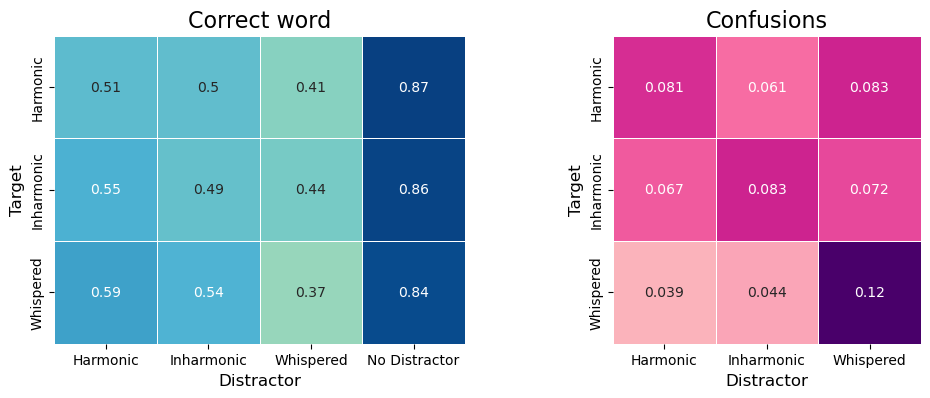

In [88]:

fontsize=16
to_plot = model_results.copy()
to_plot.distractor_harmonicity = pd.CategoricalIndex(to_plot.distractor_harmonicity, categories=['Harmonic', 'Inharmonic', 'Whispered', 'No Distractor'])
to_plot.sort_values('distractor_harmonicity', inplace=True)

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)

# cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
# cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])
# make heatmpas square 
axs[0].set_aspect('equal')
axs[1].set_aspect('equal')

# scale size of  colorbar to match heatmap
cbar_kws = {"shrink": .7,}

total_acc = to_plot.groupby(["target_harmonicity", "distractor_harmonicity"])['accuracy'].mean()
sns.heatmap(total_acc.unstack(), vmin=0, vmax=total_acc.max(), annot=True, cmap='GnBu', cbar=False, linewidth=.5, ax=axs[0])

total_con = model_results[model_results.distractor_harmonicity != 'No Distractor'].groupby(['target_harmonicity', 'distractor_harmonicity'])['confusions'].mean()
g = sns.heatmap(total_con.unstack(), vmin=0, vmax=total_con.max(), annot=True, cmap='RdPu', cbar=False, linewidth=.5,  ax=axs[1]) # cbar_kws=cbar_kws,

axs[0].set_title("Correct word", fontsize=fontsize)#xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# for ax, row in zip(axs[1], rows):
axs[1].set_title("Confusions", fontsize=fontsize) # , xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# change axis labels for both heatmaps
for ax in axs:
    # ax.set_xticklabels(np.arange(-90, 91, 30), fontsize=fontsize-4)
    # ax.set_yticklabels(np.arange(-90, 91, 30), fontsize=fontsize-4)
    ax.set_xlabel('Distractor', fontsize=fontsize-4)
    ax.set_ylabel('Target', fontsize=fontsize-4)


# plt.savefig(outfig_dest/'harmonicity_heatmaps.svg', trasnsparent=True, bbox_inches='tight')

# plt.tight_layout()

### Plot difference of differences 

$( \text{acc}_{human} - \text{conf}_{human}) - ( \text{acc}_{model} - \text{conf}_{model})$ 

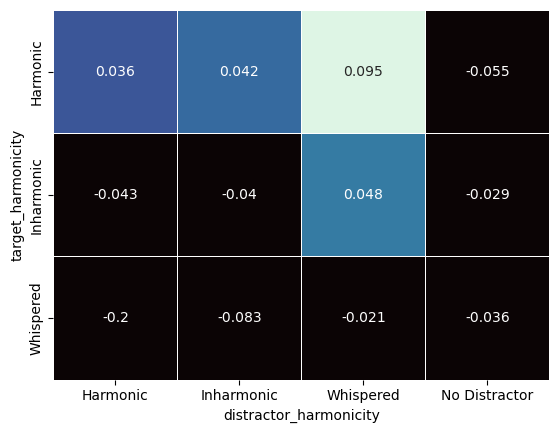

In [89]:

fontsize=16
pard_data = part_summary_df.copy()
pard_data = pard_data[pard_data.target_harmonicity != 'catch_trial']
pard_data.distractor_harmonicity = pd.CategoricalIndex(pard_data.distractor_harmonicity, categories=['Harmonic', 'Inharmonic', 'Whispered', 'No Distractor'])
pard_data.sort_values('distractor_harmonicity', inplace=True)

part_acc = pard_data.groupby(["target_harmonicity", "distractor_harmonicity"])['adjusted_accuracy_mean'].mean()
part_conf = pard_data.groupby(['target_harmonicity', 'distractor_harmonicity'])['adjusted_confusions_mean'].mean()

human_delta = part_acc - part_conf

model_data = model_results.copy()
model_data.distractor_harmonicity = pd.CategoricalIndex(model_data.distractor_harmonicity, categories=['Harmonic', 'Inharmonic', 'Whispered', 'No Distractor'])
model_data.sort_values('distractor_harmonicity', inplace=True)
model_acc = model_data.groupby(["target_harmonicity", "distractor_harmonicity"])['accuracy'].mean()
model_conf = model_data.groupby(['target_harmonicity', 'distractor_harmonicity'])['confusions'].mean()

model_delta = model_acc - model_conf

delta_of_delta = human_delta - model_delta
g = sns.heatmap(delta_of_delta.unstack(), vmin=0, vmax=delta_of_delta.max(), annot=True, cmap='mako', cbar=False, linewidth=.5) # cbar_kws=cbar_kws,

# axs[0].set_title("Correct word", fontsize=fontsize)#xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# # for ax, row in zip(axs[1], rows):
# axs[1].set_title("Confusions", fontsize=fontsize) # , xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# # change axis labels for both heatmaps
# for ax in axs:
#     # ax.set_xticklabels(np.arange(-90, 91, 30), fontsize=fontsize-4)
#     # ax.set_yticklabels(np.arange(-90, 91, 30), fontsize=fontsize-4)
#     ax.set_xlabel('Distractor', fontsize=fontsize-4)
#     ax.set_ylabel('Target', fontsize=fontsize-4)


# # plt.savefig(outfig_dest/'harmonicity_heatmaps.svg', trasnsparent=True, bbox_inches='tight')

# # plt.tight_layout()

### Conform data to plot 

In [90]:
model_results.distractor_harmonicity.unique()

array(['Harmonic', 'Inharmonic', 'No Distractor', 'Whispered'],
      dtype=object)

In [91]:
melted_model_results = pd.melt(model_results, id_vars=['target_harmonicity', 'distractor_harmonicity'],
        value_vars=['accuracy', 'confusions'],
        value_name = 'hits',
        var_name = 'attended_stream')

# melted_model_results['attended_stream'][melted_model_results['attended_stream'] == 'accuracy'] = "Cued stream"
# melted_model_results['attended_stream'][melted_model_results['attended_stream'] == 'confusions']= "Uncued stream"
melted_model_results.loc[melted_model_results['attended_stream'] == 'accuracy', 'attended_stream'] = "Cued stream"
melted_model_results.loc[melted_model_results['attended_stream'] == 'confusions', 'attended_stream'] =  "Uncued stream"


IDX_no_dist_confs = melted_model_results.loc[(melted_model_results['distractor_harmonicity'] == 'No Distractor') & (melted_model_results.attended_stream == 'Uncued stream') ].index.values
melted_model_results = melted_model_results[~melted_model_results.index.isin(IDX_no_dist_confs)]
melted_model_results.loc[melted_model_results['distractor_harmonicity'] == 'No Distractor', 'attended_stream'] = "Single sentence"
melted_model_results['group'] = 'Model'

In [92]:
part_summary_df.target_harmonicity.unique()

array(['Harmonic', 'Inharmonic', 'Whispered'], dtype=object)

In [93]:
melted_participant_results = pd.melt(part_summary_df, id_vars=['id_subject', 'target_harmonicity', 'distractor_harmonicity'],
        value_vars=['adjusted_accuracy_mean', 'adjusted_confusions_mean'],
        value_name = 'hits',
        var_name = 'attended_stream')

melted_participant_results.loc[melted_participant_results['attended_stream'] == 'adjusted_accuracy_mean', 'attended_stream'] = "Cued stream"
melted_participant_results.loc[melted_participant_results['attended_stream'] == 'adjusted_confusions_mean', 'attended_stream'] =  "Uncued stream"

IDX_no_dist_confs = melted_participant_results.loc[(melted_participant_results['distractor_harmonicity'] == 'No Distractor') & (melted_participant_results.attended_stream == 'Uncued stream') ].index.values
melted_participant_results = melted_participant_results[~melted_participant_results.index.isin(IDX_no_dist_confs)]
melted_participant_results.loc[melted_participant_results['distractor_harmonicity'] == 'No Distractor', 'attended_stream'] = "Single sentence"
melted_participant_results['group'] = f'Participants (N = {melted_participant_results.id_subject.nunique()})'

#### merge human and model results

In [94]:
melted_results = pd.concat([melted_participant_results, melted_model_results], axis=0, ignore_index=True)
melted_results

,id_subject,target_harmonicity,distractor_harmonicity,attended_stream,hits,group
0,5c8ba607c5366c0001d022cb,Harmonic,Harmonic,Cued stream,0.466667,Participants (N = 23)
1,5c8ba607c5366c0001d022cb,Harmonic,Inharmonic,Cued stream,0.533333,Participants (N = 23)
2,5c8ba607c5366c0001d022cb,Harmonic,No Distractor,Single sentence,0.800000,Participants (N = 23)
3,5c8ba607c5366c0001d022cb,Harmonic,Whispered,Cued stream,0.666667,Participants (N = 23)
4,5c8ba607c5366c0001d022cb,Inharmonic,Harmonic,Cued stream,0.666667,Participants (N = 23)
...,...,...,...,...,...,...
8038,NaN,Whispered,Whispered,Uncued stream,0.000000,Model
8039,NaN,Whispered,Whispered,Uncued stream,0.000000,Model
8040,NaN,Whispered,Whispered,Uncued stream,0.000000,Model
8041,NaN,Whispered,Whispered,Uncued stream,0.000000,Model


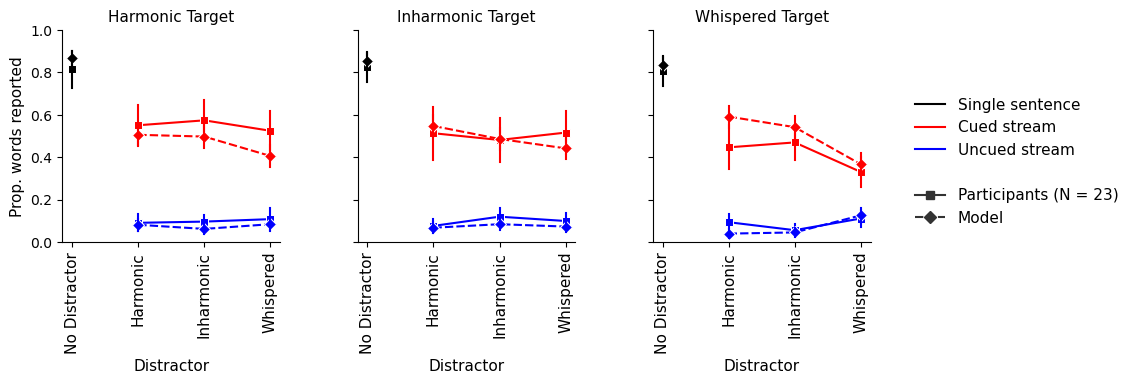

In [95]:
order = ["No Distractor", 'Harmonic', 'Inharmonic', 'Whispered']


hues = ['k', 'r', 'b']
hue_order = ['Single sentence', 'Cued stream', 'Uncued stream']
fontsize=11

to_plot = melted_results.copy()
to_plot.distractor_harmonicity = pd.CategoricalIndex(to_plot.distractor_harmonicity, categories=['No Distractor', 'Harmonic', 'Inharmonic', 'Whispered'])
to_plot.sort_values('distractor_harmonicity', inplace=True)



g = sns.relplot(kind='line',
    data=to_plot,
    col='target_harmonicity',
    col_order=[ 'Harmonic', 'Inharmonic', 'Whispered'],
    y='hits',
    hue = 'attended_stream', hue_order=hue_order,
    palette=hues,
    # order = order,
    x='distractor_harmonicity',
    style='group', style_order=[f'Participants (N = {melted_participant_results.id_subject.nunique()})', 'Model'],
    markers=['s', 'D'],
    sort=False,
#     hue='distractor_harmonicity', hue_order=hue_order, palette=distractor_palette,
#     col='subject',
    err_style='bars',
    seed=1, 
    errorbar=('se', 2),
    height=3, aspect=1
)


g.set_axis_labels("Distractor", "Prop. words reported", size=fontsize)
g.set_xticklabels(rotation=90, size=fontsize)
# g.set_xticklabels(rotation=0, size=fontsize)

# g.set_yticklabels(size=fontsize)

g.set_titles("{col_name} Target", size=fontsize)
g.legend.texts[0].set_text('')
g.legend.texts[4].set_text('')

# plt.yscale('log')
sns.move_legend(g, title='', 
                loc="center right", bbox_to_anchor=(1.05, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
         
# plt.tick_params(axis='both', which='major', labelsize=16)

plt.ylim(0,1)
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
# g.fig.suptitle('Best binaural model performance on \ninharmonic and whispered speech', size=fontsize)
# g.fig.tight_layout()


### Original-style figure 

In [96]:
to_plot.distractor_harmonicity.unique()

['No Distractor', 'Harmonic', 'Inharmonic', 'Whispered']
Categories (4, object): ['No Distractor', 'Harmonic', 'Inharmonic', 'Whispered']

Text(0.5, 0.98, 'Effect of inharmonicity on attentional selection')

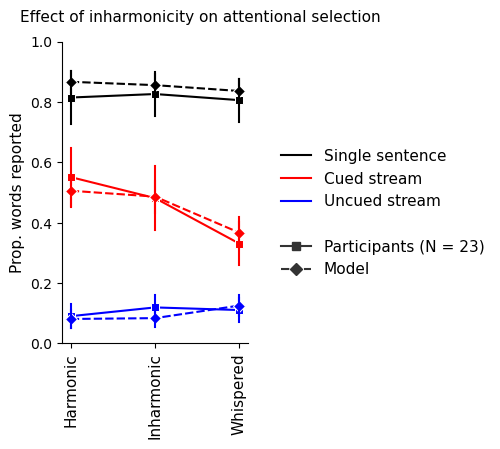

In [97]:
order = ['Harmonic', 'Inharmonic', 'Whispered']


hues = ['k', 'r', 'b']
hue_order = ['Single sentence', 'Cued stream', 'Uncued stream']
fontsize=11

to_plot = melted_results[(melted_results.target_harmonicity == melted_results.distractor_harmonicity) | (melted_results.distractor_harmonicity == 'No Distractor')]
no_dist_IXS = to_plot[to_plot.distractor_harmonicity == 'No Distractor'].index.values
to_plot.loc[no_dist_IXS, 'distractor_harmonicity'] = to_plot.loc[no_dist_IXS, 'target_harmonicity'] 
to_plot =to_plot[to_plot.distractor_harmonicity != 'No Distractor']

# g = sns.catplot(kind='point',
#     data=to_plot,
#     # col='target_harmonicity',
#      y='hits',
#     hue = 'attended_stream', hue_order=hue_order,
#     palette=hues,
#     order = order,
#     # markers='.',
#     x='distractor_harmonicity',
# #     hue='distractor_harmonicity', hue_order=hue_order, palette=distractor_palette,
# #     col='subject',
#     seed=1, 
#     errorbar=('ci', 95),
#     height=6, aspect=.75
# )

g = sns.relplot(kind='line',
    data=to_plot,
    # col='target_harmonicity',
    # col_order=[ 'Harmonic', 'Inharmonic', 'Whispered'],
    y='hits',
    hue = 'attended_stream', hue_order=hue_order,
    palette=hues,
    # order = order,
    x='distractor_harmonicity',
    style='group', style_order=[f'Participants (N = {melted_participant_results.id_subject.nunique()})', 'Model'],
    markers=['s', 'D'],
    sort=False,
#     hue='distractor_harmonicity', hue_order=hue_order, palette=distractor_palette,
#     col='subject',
    err_style='bars',
    seed=1, 
    errorbar=('se', 2),
    height=4, aspect=.75
)


g.set_axis_labels("", "Prop. words reported", size=fontsize)
g.set_xticklabels(rotation=90, size=fontsize)

g.legend.set_title("")
# plt.yscale('log')
sns.move_legend(g, title='', 
                loc="center right",  bbox_to_anchor=(1.1, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
g.legend.texts[0].set_text('')
g.legend.texts[4].set_text('')

plt.ylim(0,1)
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Effect of inharmonicity on attentional selection', size=fontsize)
# g.fig.tight_layout()


#### reformat dataframe 

In [98]:
combined_df.columns

NameError: name 'combined_df' is not defined

In [151]:
part_summary_df['group'] = f'Participants (N = {part_summary_df.id_subject.nunique()})'
model_results['group'] = 'Model'
model_results.rename(columns={"adjusted_accuracy":"adjusted_accuracy_mean", "adjusted_confusions": "adjusted_confusions_mean"}, inplace=True)

combined_df = pd.concat([part_summary_df, model_results], axis=0, ignore_index=True)
grouped_df = combined_df.groupby(['group','target_harmonicity', 'distractor_harmonicity']).agg({"adjusted_accuracy_mean":'mean', "adjusted_confusions_mean":'mean'}).reset_index()
grouped_df['recognition_delta'] = grouped_df['adjusted_accuracy_mean'] - grouped_df['adjusted_confusions_mean']


In [ ]:
target_conds = ['Harmonic', 'Inharmonic', 'Whispered']
target_pal = sns.husl_palette(len(target_conds), s=.45)
target_lut = dict(zip(map(str, target_conds), target_pal))




### Same plot but just model

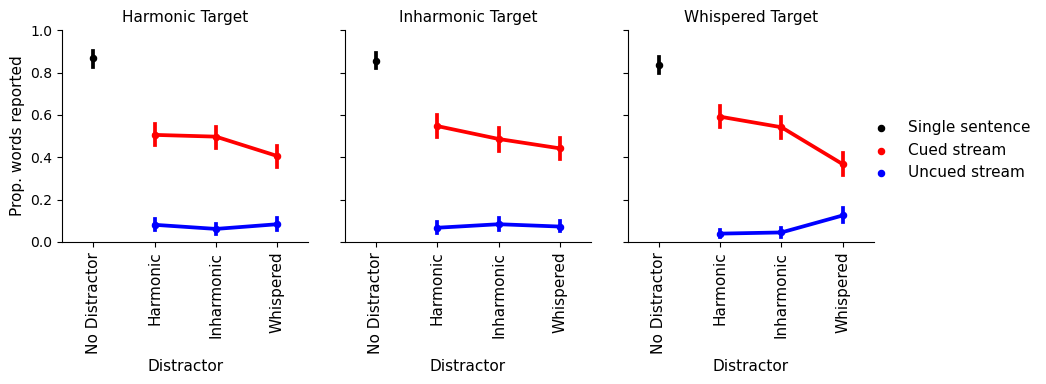

In [107]:
order = ["No Distractor", 'Harmonic', 'Inharmonic', 'Whispered']


hues = ['k', 'r', 'b']
hue_order = ['Single sentence', 'Cued stream', 'Uncued stream']
fontsize=11


g = sns.catplot(kind='point',
    data=melted_model_results,
    col='target_harmonicity', y='hits',
    hue = 'attended_stream', hue_order=hue_order,
    palette=hues,
    order = order,
    markers='.',
    x='distractor_harmonicity',
#     hue='distractor_harmonicity', hue_order=hue_order, palette=distractor_palette,
#     col='subject',
    seed=1, 
    errorbar=('ci', 95),
    height=3, aspect=1
)


g.set_axis_labels("Distractor", "Prop. words reported", size=fontsize)
g.set_xticklabels(rotation=90, size=fontsize)
# g.set_xticklabels(rotation=0, size=fontsize)

# g.set_yticklabels(size=fontsize)

g.set_titles("{col_name} Target", size=fontsize)
g.legend.set_title("")
# plt.yscale('log')
sns.move_legend(g, title='', 
                loc="center right", bbox_to_anchor=(1, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)

plt.ylim(0,1)
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
# g.fig.suptitle('Best binaural model performance on \ninharmonic and whispered speech', size=fontsize)
# g.fig.tight_layout()


Text(0.5, 0.98, 'Model performance on \ninharmonic and whispered speech')

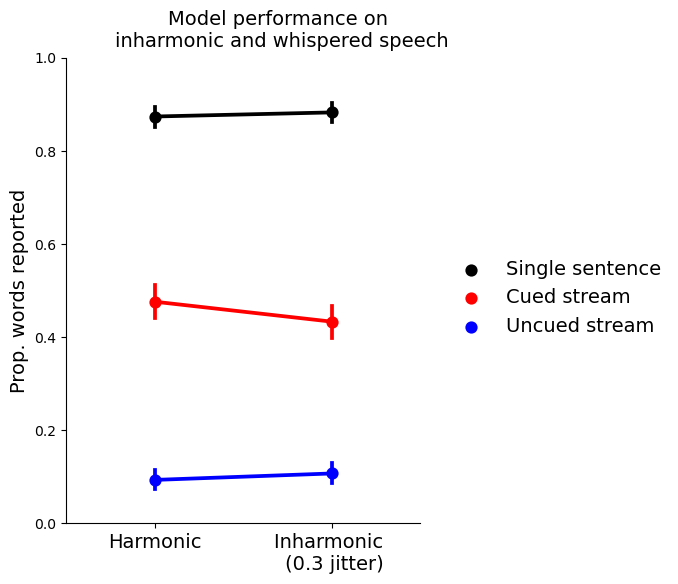

In [38]:
order = ['Harmonic', 'Inharmonic \n (0.3 jitter)']


hues = ['k', 'r', 'b']
hue_order = ['Single sentence', 'Cued stream', 'Uncued stream']
fontsize=14


g = sns.catplot(kind='point',
    data=spch_rslts,
    x='distractor_condition', y='hits',
    hue = 'attended_stream', hue_order=hue_order,
    palette=hues,
    order = order,
#     hue='distractor_condition', hue_order=hue_order, palette=distractor_palette,
#     col='subject',
    seed=1, 
    height=6, aspect=0.75
)


g.set_axis_labels("", "Prop. words reported", size=fontsize)
g.set_xticklabels(rotation=0, size=fontsize)
# g.set_xticklabels(rotation=0, size=fontsize)

# g.set_yticklabels(size=fontsize)

# g.set_titles("{col_name} performance", size=fontsize)
g.legend.set_title("")
# plt.yscale('log')
sns.move_legend(g, title='', 
                loc="center right", bbox_to_anchor=(1.15, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)

plt.ylim(0,1)
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Model performance on \ninharmonic and whispered speech', size=fontsize)
# g.fig.tight_layout()

In [167]:
melted_results.distractor_condition.unique()

array(['Harmonic', 'No Distractor', 'Inharmonic', 'Whispered'],
      dtype=object)

In [176]:
to_plot.distractor_condition.unique()

array(['Harmonic', 'Harmonic Clean', 'Whispered', 'Whispered Clean',
       'Inharmonic \n (0.3 jitter)', 'Inharmonic \n (0.3 jitter) Clean'],
      dtype=object)

In [191]:
all_results.columns

Index(['true_word_ix', 'orig_df_ix', 'model_confidence', 'accuracy',
       'pred_word_ix', 'target_condition', 'distractor_condition',
       'distractor_condition_str', 'guessed_word', 'true_word',
       'distractor_words', 'distractor_sex', 'snr', 'target_sex', 'confusion'],
      dtype='object')

## Recreate popham figure 

Text(0.5, 0.98, 'Popham-style experiment with SWC signals')

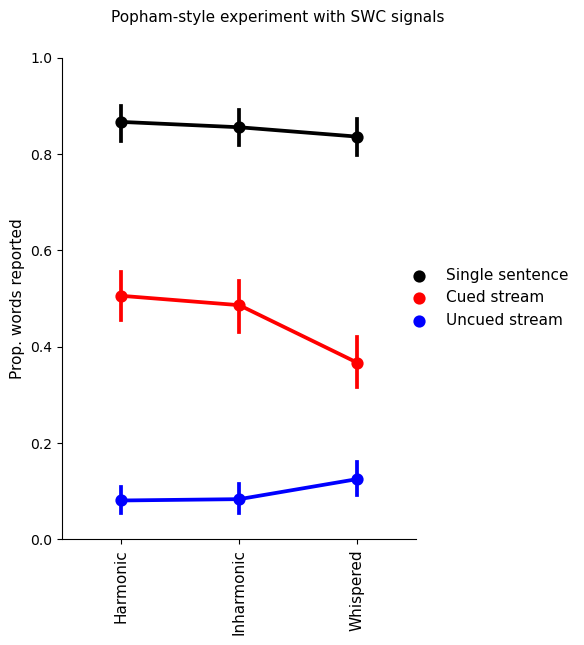

In [120]:
order = ['Harmonic', 'Inharmonic', 'Whispered']


hues = ['k', 'r', 'b']
hue_order = ['Single sentence', 'Cued stream', 'Uncued stream']
fontsize=11

to_plot = melted_results[(melted_results.target_harmonicity == melted_results.distractor_harmonicity) | (melted_results.distractor_harmonicity == 'No Distractor')]
no_dist_IXS = to_plot[to_plot.distractor_harmonicity == 'No Distractor'].index.values
to_plot.loc[no_dist_IXS, 'distractor_harmonicity'] = to_plot.loc[no_dist_IXS, 'target_harmonicity'] 


g = sns.catplot(kind='point',
    data=to_plot,
    # col='target_harmonicity',
     y='hits',
    hue = 'attended_stream', hue_order=hue_order,
    palette=hues,
    order = order,
    # markers='.',
    x='distractor_harmonicity',
#     hue='distractor_harmonicity', hue_order=hue_order, palette=distractor_palette,
#     col='subject',
    seed=1, 
    errorbar=('ci', 95),
    height=6, aspect=.75
)


g.set_axis_labels("", "Prop. words reported", size=fontsize)
g.set_xticklabels(rotation=90, size=fontsize)

g.legend.set_title("")
# plt.yscale('log')
sns.move_legend(g, title='', 
                loc="center right", bbox_to_anchor=(1, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)

plt.ylim(0,1)
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Popham-style experiment with SWC signals', size=fontsize)
# g.fig.tight_layout()
